[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZeruiW/frontier-ai-courses/blob/main/C00_VLM_Multimodal_Course/06_highres_video/06_highres_video.ipynb)

# 06 · 高分辨率、任意分辨率与视频 (High-Res, Any-Res & Video)

**配套讲解**：`06_讲解.html` · **算力**：前半段纯 numpy/PIL/matplotlib，CPU 即可；Qwen2-VL 推理段需 GPU

本 notebook 把讲解里的核心机制全部动手验证一遍：

1. **手写 AnyRes tiling**（纯 numpy/PIL）：把一张高分辨率图切成网格子图 + 全局缩略图，数清 token，与单张 336 裁切对比
2. **token 数 vs 分辨率 scaling**：对 [336, 672, 1008, 1344] 算 patch16 下的视觉 token 数，画出二次增长曲线
3. 跑 `Qwen/Qwen2-VL-2B-Instruct`（原生动态分辨率）对一张高分辨率图做 VQA，打印 `image_grid_thw` 看 token 如何自适应
4. **视频**：采样若干帧喂 Qwen2-VL 做视频问答，观察 帧数 ↑ → token 预算 ↑
5. 小结表（分辨率 → token → 成本）+ 练习
6. **3 道 ✏️ 练习**：AnyRes token 计算、best-fit 网格选择、token 预算下的视频均匀抽帧（纯 Python，CPU 可跑，含参考答案）

> 贯穿主线：**视觉 token 数 ↔ 细节保真 ↔ 上下文 / 延迟 / 成本**。这条三角权衡是本章一切技术的博弈对象。

In [1]:
import math
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# torch 仅 Qwen2-VL 段需要；前半段没有 torch 也能跑
try:
    import torch
    device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"torch version = {torch.__version__}")
    print(f"使用设备 device = {device}")
except ImportError:
    device = "cpu"
    print("未检测到 torch —— 前半段(AnyRes/scaling)仍可运行，Qwen2-VL 段需 GPU + torch")


torch version = 2.11.0+cu128
使用设备 device = cuda


## 1. 准备一张"高分辨率文档"样例图

为了离线可复现，我们用 PIL 合成一张 1344×1344 的"发票/文档"，上面写满小字。
真实场景里换成任意高分辨率截图 / 扫描件即可。重点是：**它的细节远超 336 的承载力**。

高分辨率文档尺寸: (1344, 1344)


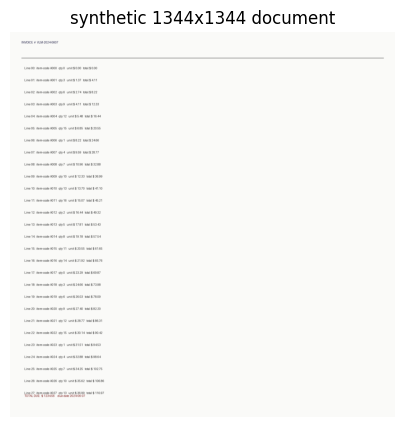

In [2]:
def make_document(size=1344):
    img = Image.new("RGB", (size, size), (250, 250, 248))
    d = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial.ttf", 18)
        big  = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial.ttf", 40)
    except Exception:
        font = ImageFont.load_default()
        big  = ImageFont.load_default()
    d.text((40, 30), "INVOICE  #  VLM-2024-0607", fill=(20, 20, 60), font=big)
    d.line((40, 90, size - 40, 90), fill=(120, 120, 120), width=2)
    # 密密麻麻的小字行（模拟文档细节）
    for i in range(28):
        y = 120 + i * 42
        d.text((50, y), f"Line {i:02d}:  item-code A{i:03d}   qty {i*3 % 17}   unit $ {i*1.37:.2f}   total $ {i*4.11:.2f}",
               fill=(40, 40, 40), font=font)
    d.text((50, size - 80), "TOTAL DUE:  $ 1234.56     due date 2024-06-07", fill=(120, 20, 20), font=big)
    return img

doc = make_document(1344)
print("高分辨率文档尺寸:", doc.size)
plt.figure(figsize=(5, 5)); plt.imshow(doc); plt.axis("off"); plt.title("synthetic 1344x1344 document"); plt.show()


## 2. 手写 AnyRes tiling（LLaVA-NeXT 思想，纯 numpy/PIL）

AnyRes 的工程解法：
1. 选一个网格（这里用 2×2，可改成动态网格）把高清图切成局部子图，每块 resize 到编码器原生分辨率 336
2. 额外保留一张**整图缩略**到 336 作为全局上下文
3. 所有子图各自过 ViT，token 拼接送进 LLM

我们不真的过 ViT，而是**复现切片几何并精确计数 token**，与"把整图直接缩到 336"对比。

In [3]:
ENC_RES   = 336   # 编码器原生分辨率
PATCH     = 14    # ViT patch 大小 (CLIP ViT-L/14)
TOK_PER_TILE = (ENC_RES // PATCH) ** 2   # 单张 336 图的视觉 token 数
print(f"单张 {ENC_RES} 图 -> {ENC_RES//PATCH} x {ENC_RES//PATCH} = {TOK_PER_TILE} 个视觉 token (patch={PATCH})")

def anyres_tiles(img, grid=(2, 2), enc_res=ENC_RES):
    '''把图切成 grid=(rows,cols) 个局部子图(各 resize 到 enc_res) + 一张全局缩略图。'''
    rows, cols = grid
    W, H = img.size
    tw, th = W // cols, H // rows
    local_tiles = []
    for r in range(rows):
        for c in range(cols):
            box = (c * tw, r * th, (c + 1) * tw, (r + 1) * th)
            local_tiles.append(img.crop(box).resize((enc_res, enc_res)))
    global_thumb = img.resize((enc_res, enc_res))
    return local_tiles, global_thumb

grid = (2, 2)
tiles, thumb = anyres_tiles(doc, grid=grid)
n_local = len(tiles)
anyres_tokens = (n_local + 1) * TOK_PER_TILE   # +1 是全局缩略图
naive_tokens  = TOK_PER_TILE                   # 整图直接缩到 336

print(f"\nAnyRes 网格 {grid[0]}x{grid[1]}: {n_local} 个局部子图 + 1 张全局缩略")
print(f"  AnyRes 总 token   = ({n_local}+1) x {TOK_PER_TILE} = {anyres_tokens}")
print(f"  朴素 336 单图 token = {naive_tokens}")
print(f"  -> AnyRes 是朴素方案的 {anyres_tokens / naive_tokens:.0f} 倍 token")
print(f"  换来的是: 每块 tile 覆盖原图 {doc.size[0]//grid[1]}px 宽度, 细节采样率提升约 {grid[1]}x")


单张 336 图 -> 24 x 24 = 576 个视觉 token (patch=14)

AnyRes 网格 2x2: 4 个局部子图 + 1 张全局缩略
  AnyRes 总 token   = (4+1) x 576 = 2880
  朴素 336 单图 token = 576
  -> AnyRes 是朴素方案的 5 倍 token
  换来的是: 每块 tile 覆盖原图 672px 宽度, 细节采样率提升约 2x


/tmp/ipykernel_15149/4204324322.py:7: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/4204324322.py:7: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/4204324322.py:7: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/4204324322.py:7: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/4204324322.py:7: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/4204324322.py:7: UserWarning: Glyph 28165 (\N{CJK UNIFIED IDEOGRAPH-6E05}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/4

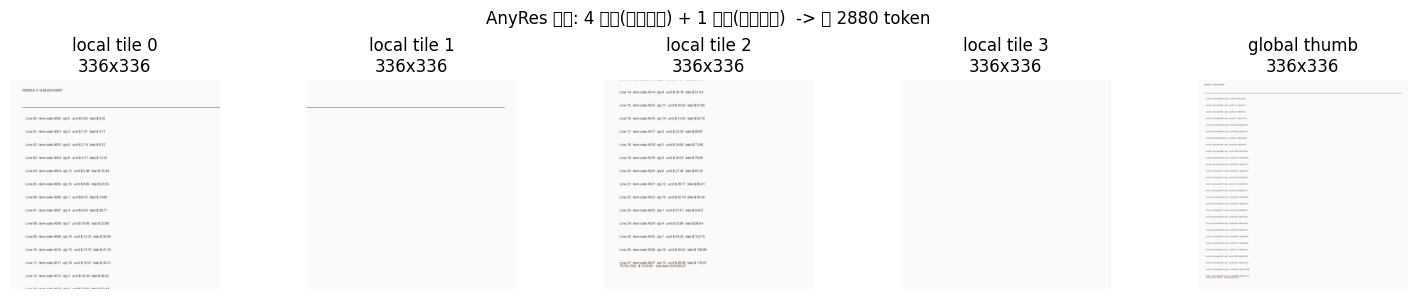

观察: 局部 tile 里的小字清晰可读, 而全局缩略图里的小字已糊成一片 —— 这正是为何二者都要保留。


In [4]:
# 可视化 AnyRes 的产物：4 个局部 tile + 1 张全局缩略
fig, axes = plt.subplots(1, n_local + 1, figsize=(3 * (n_local + 1), 3))
for i, t in enumerate(tiles):
    axes[i].imshow(t); axes[i].axis("off"); axes[i].set_title(f"local tile {i}\n336x336")
axes[-1].imshow(thumb); axes[-1].axis("off"); axes[-1].set_title("global thumb\n336x336")
plt.suptitle(f"AnyRes 产物: {n_local} 局部(看清小字) + 1 全局(看懂版面)  -> 共 {anyres_tokens} token")
plt.tight_layout(); plt.show()
print("观察: 局部 tile 里的小字清晰可读, 而全局缩略图里的小字已糊成一片 —— 这正是为何二者都要保留。")


## 3. token 数 vs 分辨率：二次增长曲线

把有效分辨率从 336 推到 1344，用"恰好铺满的方形网格 + 1 张全局图"计算 AnyRes token 数。
注意横轴是**边长**，但 token 随**面积**走，所以是一条向上弯的二次曲线 —— 这是 token 压缩存在的根本理由。

有效分辨率  336  网格 1x1(+全局)  视觉 token =  1152  (相对336: 2x)
有效分辨率  672  网格 2x2(+全局)  视觉 token =  2880  (相对336: 5x)
有效分辨率 1008  网格 3x3(+全局)  视觉 token =  5760  (相对336: 10x)
有效分辨率 1344  网格 4x4(+全局)  视觉 token =  9792  (相对336: 17x)


/tmp/ipykernel_15149/2139937579.py:21: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/2139937579.py:21: UserWarning: Glyph 25928 (\N{CJK UNIFIED IDEOGRAPH-6548}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/2139937579.py:21: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/2139937579.py:21: UserWarning: Glyph 36776 (\N{CJK UNIFIED IDEOGRAPH-8FA8}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/2139937579.py:21: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/tmp/

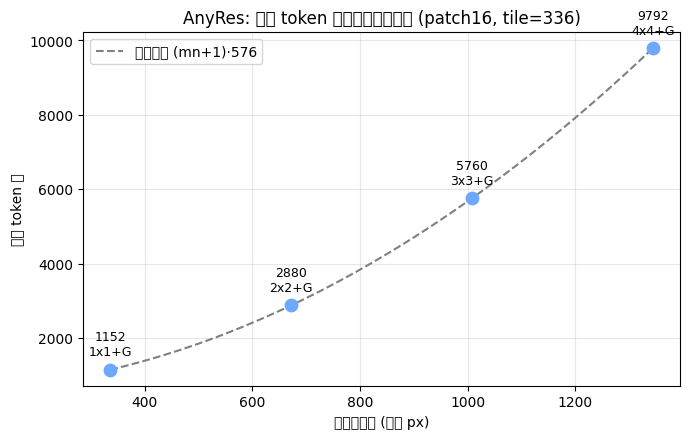

结论: 边长×2 -> 面积×4 -> token≈×4。self-attention 是 O(L^2), token×4 则注意力计算≈×16。高分辨率从不免费。


In [5]:
resolutions = [336, 672, 1008, 1344]
tok_counts, grids = [], []
for R in resolutions:
    side = R // ENC_RES                      # 每边铺几块 336
    n_local = side * side
    tok = (n_local + 1) * TOK_PER_TILE       # +1 全局缩略
    tok_counts.append(tok); grids.append(f"{side}x{side}+G")
    print(f"有效分辨率 {R:>4}  网格 {side}x{side}(+全局)  视觉 token = {tok:>5}  (相对336: {tok/TOK_PER_TILE:.0f}x)")

# 理论二次曲线对照
xs = np.linspace(336, 1344, 100)
ys = ((xs / ENC_RES) ** 2 + 1) * TOK_PER_TILE

plt.figure(figsize=(7, 4.5))
plt.plot(xs, ys, "--", color="gray", label="二次增长 (mn+1)·576")
plt.scatter(resolutions, tok_counts, s=80, color="#6ea8fe", zorder=3)
for R, t, g in zip(resolutions, tok_counts, grids):
    plt.annotate(f"{t}\n{g}", (R, t), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
plt.xlabel("有效分辨率 (边长 px)"); plt.ylabel("视觉 token 数")
plt.title("AnyRes: 视觉 token 随分辨率二次增长 (patch16, tile=336)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("结论: 边长×2 -> 面积×4 -> token≈×4。self-attention 是 O(L^2), token×4 则注意力计算≈×16。高分辨率从不免费。")


## 4. 原生动态分辨率：跑 Qwen2-VL-2B 看 token 如何自适应

**算力提示**：`Qwen/Qwen2-VL-2B-Instruct` 半精度约需 **~6GB 显存**，Colab T4（16GB）默认用 fp16 直接跑，不需要量化；
下面留了一个 `USE_4BIT` 开关给显存特别紧张的场景（可压到 ~3GB），但默认关闭。无 GPU 时本段会跳过（前面 1–3 段已足够说明问题）。

关键观察对象是 `inputs.image_grid_thw` —— Qwen2-VL **按原图分辨率决定 token 数**，
而不是固定 576。grid 是 `(T, H, W)` 形式的 patch 网格（已含时间维 T），实际视觉 token 数 = `prod(grid_thw) / (merge_size**2)`。

In [ ]:
USE_4BIT = False
   # 2B 模型 fp16 只要 ~6GB，T4(16GB) 默认不需要量化；显存特别紧张时才设 True

qwen_ready = False
if device == "cuda":
    try:
        from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
        try:
            from transformers import BitsAndBytesConfig
        except Exception:
            BitsAndBytesConfig = None

        MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
        # Qwen2-VL 支持按 min/max pixels 控制 token 预算上限(防止超大图爆 token)
        processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=1280*28*28)

        load_kwargs = dict(torch_dtype=torch.float16, device_map="auto")
        if USE_4BIT and BitsAndBytesConfig is not None:
            load_kwargs["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)
        model = Qwen2VLForConditionalGeneration.from_pretrained(MODEL_ID, **load_kwargs).eval()
        qwen_ready = True
        print(f"已加载 {MODEL_ID}  (4bit={USE_4BIT and BitsAndBytesConfig is not None})")
    except Exception as e:
        print("加载 Qwen2-VL 失败(可能缺权重/显存/网络):", repr(e))
else:
    print(f"当前 device={device}，跳过 Qwen2-VL 推理段。前面 1–3 段不依赖它。")


In [15]:
if qwen_ready:
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": doc},
            {"type": "text",  "text": "What is the TOTAL DUE shown in this invoice, and on what date is it due?"},
        ],
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # 高分辨率单图：直接把 PIL 图传进 processor(images=...)
    inputs = processor(text=[text], images=[doc], padding=True, return_tensors="pt").to(model.device)

    grid = inputs.image_grid_thw[0]                       # (T, H, W) patch 网格
    merge = processor.image_processor.merge_size          # 2x2 merger
    n_vis_tokens = int(grid.prod().item() // (merge ** 2))
    print("image_grid_thw =", grid.tolist(), " (T, H_patches, W_patches)")
    print(f"merge_size = {merge}  ->  实际视觉 token 数 = prod(grid)/{merge}^2 = {n_vis_tokens}")
    print("注意: 这个数字是按 *这张图的分辨率* 自适应算出来的, 不是固定 576/1024。")

    with torch.no_grad():
        gen = model.generate(**inputs, max_new_tokens=64)
    out = processor.batch_decode(gen[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    print("\n模型回答:", out.strip())
else:
    print("(Qwen2-VL 未就绪，跳过)")


image_grid_thw = [1, 70, 70]  (T, H_patches, W_patches)
merge_size = 2  ->  实际视觉 token 数 = prod(grid)/2^2 = 1225
注意: 这个数字是按 *这张图的分辨率* 自适应算出来的, 不是固定 576/1024。

模型回答: The TOTAL DUE shown in this invoice is $123,456. It is due on June 6, 2024.


In [16]:
# 对比: 同一张图缩到不同分辨率, 看 Qwen2-VL 的视觉 token 数如何变化
if qwen_ready:
    print(f"{'输入分辨率':>10} | {'image_grid_thw':>20} | {'视觉 token':>10}")
    print("-" * 48)
    merge = processor.image_processor.merge_size
    for R in [336, 672, 1008, 1344]:
        img_r = doc.resize((R, R))
        ii = processor(text=["x"], images=[img_r], return_tensors="pt")
        g = ii.image_grid_thw[0]
        n = int(g.prod().item() // (merge ** 2))
        print(f"{R:>8}px | {str(g.tolist()):>20} | {n:>10}")
    print("\n看到没: 输入越大 -> grid 越大 -> 视觉 token 越多。token 预算自适应于内容, 这就是 Native Dynamic Resolution。")
else:
    print("(Qwen2-VL 未就绪，跳过)")


     输入分辨率 |       image_grid_thw |   视觉 token
------------------------------------------------
     336px |          [1, 32, 32] |        256
     672px |          [1, 48, 48] |        576
    1008px |          [1, 70, 70] |       1225
    1344px |          [1, 70, 70] |       1225

看到没: 输入越大 -> grid 越大 -> 视觉 token 越多。token 预算自适应于内容, 这就是 Native Dynamic Resolution。


## 5. 视频：帧采样 + 视频问答，观察 帧数 ↑ → token ↑

视频 = 图像 × 时间。我们从一段 clip 采样若干帧喂 Qwen2-VL。
- 若本地/可下载到短视频，用 OpenCV 均匀采样帧；
- 否则用 PIL **合成一段渐变运动帧**作为占位（一个色块从左移到右），保证离线可跑。

Qwen2-VL 的视频处理推荐用 `qwen_vl_utils.process_vision_info`；这里为离线鲁棒，**直接把帧列表作为 `video` 传入 processor**，
效果等价。重点观察：**帧数翻倍 → 视频 token 预算翻倍**。

/tmp/ipykernel_15149/3655395622.py:45: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.suptitle(f"采样得到的 {len(frames)} 帧"); plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/3655395622.py:45: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.suptitle(f"采样得到的 {len(frames)} 帧"); plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/3655395622.py:45: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  plt.suptitle(f"采样得到的 {len(frames)} 帧"); plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/3655395622.py:45: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  plt.suptitle(f"采样得到的 {len(frames)} 帧"); plt.tight_layout(); plt.show()
/tmp/ipykernel_15149/3655395622.py:45: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.suptitle(f"采样得到的 {len(frames)} 帧"); plt.tight_l

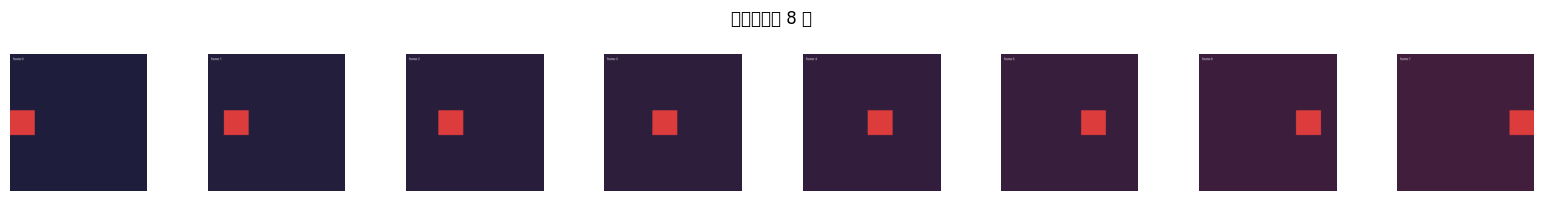

In [17]:
def synth_video_frames(n_frames=8, size=448):
    '''合成一段运动帧: 一个红块从左移到右, 背景渐变。离线占位用。'''
    frames = []
    for i in range(n_frames):
        img = Image.new("RGB", (size, size), (30 + i * 5, 30, 60))
        d = ImageDraw.Draw(img)
        x = int((size - 80) * i / max(1, n_frames - 1))
        d.rectangle([x, size // 2 - 40, x + 80, size // 2 + 40], fill=(220, 60, 60))
        d.text((10, 10), f"frame {i}", fill=(240, 240, 240))
        frames.append(img)
    return frames

def load_video_frames(path, n_frames=8):
    '''用 OpenCV 从本地视频均匀采样 n_frames 帧; 失败则回退到合成帧。'''
    try:
        import cv2
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            raise RuntimeError("读不到帧数")
        idxs = np.linspace(0, total - 1, n_frames).astype(int)
        frames = []
        for idx in idxs:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ok, frame = cap.read()
            if not ok:
                break
            frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        cap.release()
        if len(frames) >= 2:
            print(f"从 {path} 均匀采样 {len(frames)} 帧 (原视频共 {total} 帧)")
            return frames
        raise RuntimeError("采样帧不足")
    except Exception as e:
        print("OpenCV 读取失败, 回退到合成帧:", repr(e))
        return synth_video_frames(n_frames)

VIDEO_PATH = "sample.mp4"   # 有本地短 clip 就放这里; 没有则自动用合成帧
import os
frames = load_video_frames(VIDEO_PATH, n_frames=8) if os.path.exists(VIDEO_PATH) else synth_video_frames(8)

fig, axes = plt.subplots(1, len(frames), figsize=(2 * len(frames), 2))
for ax, fr in zip(axes, frames):
    ax.imshow(fr); ax.axis("off")
plt.suptitle(f"采样得到的 {len(frames)} 帧"); plt.tight_layout(); plt.show()


In [18]:
# 喂 Qwen2-VL 做视频问答, 并对比 不同帧数 -> token 预算
if qwen_ready:
    merge = processor.image_processor.merge_size

    def video_token_count(frame_list):
        ii = processor(text=["x"], videos=[frame_list], return_tensors="pt")
        g = ii.video_grid_thw[0]                      # (T, H, W)
        return int(g.prod().item() // (merge ** 2)), g.tolist()

    print(f"{'帧数':>6} | {'video_grid_thw':>18} | {'视频 token':>10}")
    print("-" * 42)
    for nf in [4, 8, 16]:
        fl = synth_video_frames(nf)
        n, g = video_token_count(fl)
        print(f"{nf:>6} | {str(g):>18} | {n:>10}")
    print("\n帧数 ↑ -> T ↑ -> 视频 token 线性 ↑。长视频(成百上千帧)会让 token 预算爆炸。\n")

    # 真正做一次视频问答
    messages = [{
        "role": "user",
        "content": [
            {"type": "video", "video": frames},
            {"type": "text",  "text": "Describe what happens across these frames. Does anything move?"},
        ],
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], videos=[frames], padding=True, return_tensors="pt").to(model.device)
    print("本次视频 video_grid_thw =", inputs.video_grid_thw[0].tolist(),
          " 视频 token =", int(inputs.video_grid_thw[0].prod().item() // (merge ** 2)))
    with torch.no_grad():
        gen = model.generate(**inputs, max_new_tokens=80)
    out = processor.batch_decode(gen[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    print("\n模型回答:", out.strip())
else:
    # 即便没跑模型, 也用纯几何估算 帧数->token 的爆炸趋势
    print("(Qwen2-VL 未就绪) 用几何估算 帧数 -> 视频 token (假设每帧压缩到 ~256 token):")
    for nf in [10, 60, 600, 3600]:
        print(f"  {nf:>5} 帧  ≈ {nf*256:>8} 视觉 token")
    print("  600 帧已 ~15万 token, 远超常见 32K 上下文 -> 必须更狠压缩/选帧/分段记忆。")


    帧数 |     video_grid_thw |   视频 token
------------------------------------------
     4 |        [2, 32, 32] |        512
     8 |        [4, 32, 32] |       1024
    16 |        [8, 32, 32] |       2048

帧数 ↑ -> T ↑ -> 视频 token 线性 ↑。长视频(成百上千帧)会让 token 预算爆炸。

本次视频 video_grid_thw = [4, 32, 32]  视频 token = 1024

模型回答: In the first frame, there is a red rectangle on a dark blue background. In the second frame, the red rectangle has moved to the right, and the background remains the same. In the third frame, the red rectangle has moved further to the right, and the background is still the same.


---
## ✏️ 练习 1：实现 `anyres_token_count`

不翻上文，自己把 AnyRes 的 token 账算清楚：给定网格 `grid=(rows, cols)`，按以下约定返回总视觉 token 数（int）：

- 每个 tile（含全局缩略图 global thumbnail）都 resize 到 `enc_res`，各贡献 `(enc_res // patch) ** 2` 个 token；
- 共 `rows * cols` 个局部 tile **+ 1 张全局缩略图**；
- 每**行** tile 末尾追加 1 个 row-separator token（模拟 LLaVA-NeXT 的 image-newline），共 `rows` 个。

**提示**：先算 `tok_per_tile = (enc_res // patch) ** 2`，总数就是 `(rows * cols + 1) * tok_per_tile + rows`，5 行以内。心算验证：`(2, 2)` 网格应得 5×576+2 = 2882，与正文第 2 节的量级一致。

In [11]:
def anyres_token_count(grid, enc_res=336, patch=14):
    # TODO: rows*cols 个局部 tile + 1 张全局缩略图，每个贡献 (enc_res//patch)**2 个 token；
    #       每行 tile 末尾再加 1 个 row-separator token（共 rows 个）
    raise NotImplementedError

In [12]:
# —— 练习 1 自测 ——
assert anyres_token_count((1, 1)) == 2 * 576 + 1                   # 1 tile + 全局缩略 + 1 个行分隔符
assert anyres_token_count((2, 2)) == 5 * 576 + 2                   # 正文同款 2x2 网格: 2882
assert anyres_token_count((2, 3)) == 7 * 576 + 2                   # 非方形网格: 6 tiles + 全局
assert anyres_token_count((4, 4)) == 17 * 576 + 4                  # 1344 全铺: 近 1 万 token
assert anyres_token_count((1, 1), enc_res=448, patch=14) == 2 * 1024 + 1   # 换 tile 分辨率: 32x32 patch
print("✅ 练习 1 通过")

NotImplementedError: 

## ✏️ 练习 2：实现 `select_best_grid`（best-fit 网格选择）

正文里我们手动指定 `grid=(2, 2)`，但 LLaVA-NeXT 实际是从一组候选网格里**自动挑最贴合原图的那个**。实现 `select_best_grid(orig_w, orig_h, candidate_grids, enc_res=336)`，对每个候选 `(rows, cols)`：

1. 候选画布尺寸 = `(cols * enc_res, rows * enc_res)`（宽 × 高，注意 cols 对应宽）；
2. 把原图**保持长宽比**缩放到恰好装进画布：`scale = min(画布宽 / orig_w, 画布高 / orig_h)`，缩放后尺寸 `(int(orig_w * scale), int(orig_h * scale))`；
3. **有效像素** `effective` = 缩放后面积，但封顶为原图面积（放大不产生新信息）；**浪费像素** `wasted` = 画布面积 − effective；
4. 选 `effective` 最大的候选；打平时选 `wasted` 最小的。返回 `(rows, cols)`。

**提示**：一个 for 循环 + 两个比较条件（`eff > best_eff` 或 `eff == best_eff and waste < best_waste`），15 行以内。边界直觉：宽图应选横向网格（cols 多）；比 336 还小的图放大不增加有效像素，所有候选的 effective 打平，于是落到 padding 最少的 `(1, 1)`——这正是"别给小图浪费大网格"的机制来源。

In [ ]:
def select_best_grid(orig_w, orig_h, candidate_grids, enc_res=336):
    # TODO: 对每个 (rows, cols) 候选:
    #   1) 画布 = (cols*enc_res, rows*enc_res)
    #   2) scale = min(画布宽/orig_w, 画布高/orig_h); 缩放后 (int(orig_w*scale), int(orig_h*scale))
    #   3) effective = min(缩放后面积, 原图面积); wasted = 画布面积 - effective
    #   4) effective 大者优, 打平时 wasted 小者优
    raise NotImplementedError

In [ ]:
# —— 练习 2 自测 ——
cands = [(1, 1), (1, 2), (2, 1), (2, 2), (1, 4), (4, 1)]
assert select_best_grid(672, 672, cands) == (2, 2)      # 方形大图 -> 2x2
assert select_best_grid(1344, 336, cands) == (1, 4)     # 宽图 -> 横向网格
assert select_best_grid(336, 1344, cands) == (4, 1)     # 高图 -> 纵向网格
assert select_best_grid(672, 336, cands) == (1, 2)      # effective 打平时, 选 wasted 最少的
assert select_best_grid(100, 100, cands) == (1, 1)      # 小图: 别浪费大网格
print("✅ 练习 2 通过")

## ✏️ 练习 3：实现 `sample_frames_under_budget`（token 预算下的视频抽帧）

第 5 节看到：帧数 ↑ → 视频 token 线性 ↑。现在反过来做工程决策——给定视频总帧数 `total_frames`、每帧 token 数 `tok_per_frame`、总 token 预算 `budget`，返回**均匀采样**的帧索引列表（int 列表）：

1. 可负担帧数 `n = min(total_frames, budget // tok_per_frame)`；
2. `n == 0` 返回 `[]`；`n == 1` 返回 `[0]`；
3. 否则返回 n 个索引：首帧 0、末帧 `total_frames - 1`，中间均匀分布——第 i 个索引为 `round(i * (total_frames - 1) / (n - 1))`。

**提示**：这就是正文 `load_video_frames` 里 `np.linspace(0, total-1, n)` 的纯 Python 版，核心一行列表推导，全函数 10 行以内。边界：预算连一帧都不够时返回空表；预算充裕时退化为逐帧 `[0, 1, ..., total_frames-1]`。

In [ ]:
def sample_frames_under_budget(total_frames, tok_per_frame, budget):
    # TODO:
    #   1) n = min(total_frames, budget // tok_per_frame)
    #   2) n == 0 -> []; n == 1 -> [0]
    #   3) 否则均匀采样: 第 i 个索引 = round(i * (total_frames - 1) / (n - 1))
    raise NotImplementedError

In [ ]:
# —— 练习 3 自测 ——
idxs = sample_frames_under_budget(total_frames=100, tok_per_frame=256, budget=2048)
assert len(idxs) == 8 and idxs[0] == 0 and idxs[-1] == 99            # 2048//256 = 8 帧, 首尾必须覆盖
assert all(a < b for a, b in zip(idxs, idxs[1:]))                    # 索引严格递增
assert sample_frames_under_budget(5, 256, 10**9) == [0, 1, 2, 3, 4]  # 预算充裕: 退化为逐帧
assert sample_frames_under_budget(100, 256, 300) == [0]              # 只够 1 帧
assert sample_frames_under_budget(100, 256, 100) == []               # 一帧都不够
print("✅ 练习 3 通过")

---
## 📖 参考答案

In [ ]:
# 练习 1 参考答案（先自己做，再对照）
def anyres_token_count(grid, enc_res=336, patch=14):
    rows, cols = grid
    tok_per_tile = (enc_res // patch) ** 2
    return (rows * cols + 1) * tok_per_tile + rows

In [ ]:
# 练习 2 参考答案（先自己做，再对照）
def select_best_grid(orig_w, orig_h, candidate_grids, enc_res=336):
    best, best_eff, best_waste = None, -1, None
    for rows, cols in candidate_grids:
        cand_w, cand_h = cols * enc_res, rows * enc_res
        scale = min(cand_w / orig_w, cand_h / orig_h)
        down_w, down_h = int(orig_w * scale), int(orig_h * scale)
        effective = min(down_w * down_h, orig_w * orig_h)
        wasted = cand_w * cand_h - effective
        if effective > best_eff or (effective == best_eff and wasted < best_waste):
            best, best_eff, best_waste = (rows, cols), effective, wasted
    return best

In [ ]:
# 练习 3 参考答案（先自己做，再对照）
def sample_frames_under_budget(total_frames, tok_per_frame, budget):
    n = min(total_frames, budget // tok_per_frame)
    if n <= 0:
        return []
    if n == 1:
        return [0]
    return [round(i * (total_frames - 1) / (n - 1)) for i in range(n)]

## 6. 小结：分辨率 → token → 成本 对照表

| 方案 | 有效分辨率 | 视觉 token (量级) | 细节保真 | 上下文/延迟成本 | 典型适用 |
|------|-----------|------------------|---------|----------------|---------|
| 固定 336 单图 | 336 | ~576 | 低（小字丢失） | 最低 | 自然图像 VQA |
| AnyRes 2×2 (LLaVA-NeXT) | 672 | ~2880 | 中高 | 5× | 文档/图表 |
| AnyRes 4×4 | 1344 | ~9800 | 高 | ~17× | 高分辨率扫描件 |
| 原生动态分辨率 (Qwen2-VL) | 自适应 | 随图变化 | 高且自适应 | 按图付费 | 任意分辨率/视频 |
| + pixel shuffle 压缩 (÷4) | 任意 | token÷4 | 略降 | 显著降 | 长上下文/多图/视频 |
| 视频 N 帧 | 每帧 ×N | 每帧 token × N | 取决于采样 | 随帧数线性爆炸 | 视频理解 |

**贯穿主线再强调一次**：*视觉 token 数 ↔ 细节保真 ↔ 上下文/延迟/成本* 三者不可兼得。
做评测时，**token 预算（max tiles / 采样帧数）必须作为一等超参与准确率一起报告**，否则横向比较不成立。

### 动手练习
1. **改网格**：把 `anyres_tiles` 的 `grid` 改成 `(3,3)` 或非方形 `(2,3)`，重新计算 token 数；思考为什么 LLaVA-NeXT 要从候选网格中挑"最贴合原图长宽比"的那个。
2. **压缩实验**：在第 3 段曲线上叠加一条"pixel shuffle ÷4"后的曲线（token 全部除以 4），直观看压缩把成本曲线整体压下来多少、代价是什么。
3. **帧数-准确率权衡**：若有真实短视频，用 `load_video_frames` 分别取 4 / 8 / 16 帧问同一个时序问题，记录回答质量与 `video_grid_thw` 的 token 数，画出"帧数 vs token vs 答对与否"。

➡️ 下一站：**模块 07 — VLM 评测体系**。我们会把本章的"token 预算 / 分辨率 / 采样"正式纳入评测协议，
学会在 DocVQA / ChartQA / VideoQA 上做受控、可复现、防作弊的评测，并把失败<em>归因</em>到视觉前端还是 LLM 后端。

---
## 🎯 真实数据胶囊题：真实图像的高分辨率 tiling

高分辨率 VLM(如 LLaVA-NeXT)把大图切成若干 tile 分别编码再拼。用真实图像，实现 K×K tiling，验证 tile 数 = K² 且能无损覆盖原图。

> 本模块新增的**真实数据**练习：用**真实图像**把本章方法跑一遍。先做 TODO，`assert` 全过即通关，文末有参考答案。

In [ ]:
import os, io, urllib.request
import numpy as np
import matplotlib.image as mpimg
CACHE=os.path.expanduser("~/.vlm_data"); os.makedirs(CACHE,exist_ok=True)
def real_image():
    "真实图像 Grace Hopper (来自 matplotlib 示例数据), 返回 (H,W,3) uint8"
    p=os.path.join(CACHE,"grace_hopper.jpg")
    if not os.path.exists(p):
        urllib.request.urlretrieve("https://raw.githubusercontent.com/matplotlib/matplotlib/main/lib/matplotlib/mpl-data/sample_data/grace_hopper.jpg", p)
    return mpimg.imread(p)

img=real_image()
print("真实大图:", img.shape[:2])

**练习**：实现 `tile_image(img, K)`：把图像切成 `K×K` 个 tile（H、W 截断到 K 整数倍），返回 tile 列表。

In [ ]:
def tile_image(img, K=3):
    # TODO: 裁到 K 整数倍；切成 K*K 个 tile（按行列均分）
    raise NotImplementedError


In [ ]:
# 自测
tiles=tile_image(img, 3)
assert len(tiles)==9, f"3x3 应有 9 个 tile, 得到 {len(tiles)}"
# 像素总数守恒(裁剪后)
H=img.shape[0]//3*3; W=img.shape[1]//3*3
assert sum(t.shape[0]*t.shape[1] for t in tiles)==H*W
assert len(tile_image(img,2))==4
print(f"高分辨率 tiling ✓  3x3 -> {len(tiles)} tiles, 覆盖 {H}x{W} 像素")


### 📖 参考答案

In [ ]:
def tile_image(img, K=3):
    H=img.shape[0]//K*K; W=img.shape[1]//K*K; img=img[:H,:W]
    h,w=H//K,W//K; tiles=[]
    for i in range(K):
        for j in range(K):
            tiles.append(img[i*h:(i+1)*h, j*w:(j+1)*w])
    return tiles
print("✓ tiling 让 VLM 在固定编码器下处理高分辨率(代价是 token 数线性增长)")